In [166]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [167]:
df = pd.read_json("./data/News_Category_Dataset_v3.json", lines= True)

df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,U.S. NEWS,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlines-passenger-banned-flight-attendant-punch-justice-department_n_632e25d3e4b0e247890329fe,"American Airlines Flyer Charged, Banned For Life After Punching Flight Attendant On Video",U.S. NEWS,"He was subdued by passengers and crew when he fled to the back of the aircraft after the confrontation, according to the U.S. attorney's office in Los Angeles.",Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets-cats-dogs-september-17-23_n_632de332e4b0695c1d81dc02,23 Of The Funniest Tweets About Cats And Dogs This Week (Sept. 17-23),COMEDY,"""Until you have a dog you don't understand what could be eaten.""",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parenting-tweets_l_632d7d15e4b0d12b5403e479,The Funniest Tweets From Parents This Week (Sept. 17-23),PARENTING,"""Accidentally put grown-up toothpaste on my toddler’s toothbrush and he screamed like I was cleaning his teeth with a Carolina Reaper dipped in Tabasco sauce.""",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-loses-discrimination-lawsuit-franklin-templeton_n_632c6463e4b09d8701bd227e,Woman Who Called Cops On Black Bird-Watcher Loses Lawsuit Against Ex-Employer,U.S. NEWS,Amy Cooper accused investment firm Franklin Templeton of unfairly firing her and branding her a racist after video of the Central Park encounter went viral.,Nina Golgowski,2022-09-22


In [168]:
df.tail()

,link,headline,category,short_description,authors,date
209522,https://www.huffingtonpost.com/entry/rim-ceo-thorsten-heins_us_5bb34b8ce4b0fa920b95c4e1,RIM CEO Thorsten Heins' 'Significant' Plans For BlackBerry,TECH,Verizon Wireless and AT&T are already promoting LTE devices including smartphones and tablets from RIM's rivals. RIM's first,"Reuters, Reuters",2012-01-28
209523,https://www.huffingtonpost.com/entry/maria-sharapova-stunned-victoria-azarenka-australian-open_us_5bb69b21e4b097869fd1b2f1,Maria Sharapova Stunned By Victoria Azarenka In Australian Open Final,SPORTS,"Afterward, Azarenka, more effusive with the press than normal, credited her coach of two years, Sam Sumyk, for his patient",,2012-01-28
209524,https://www.huffingtonpost.com/entry/super-bowl-upsets-the-mos_us_5bb69b1de4b097869fd1b26d,"Giants Over Patriots, Jets Over Colts Among Most Improbable Super Bowl Upsets Of All Time (VIDEOS)",SPORTS,"Leading up to Super Bowl XLVI, the most talked about game could end up being one that occurred a few years ago. After all",,2012-01-28
209525,https://www.huffingtonpost.com/entry/aldon-smith-arrested-dui-49ers_us_5bb69b25e4b097869fd1b33c,Aldon Smith Arrested: 49ers Linebacker Busted For DUI,SPORTS,CORRECTION: An earlier version of this story incorrectly stated the location of KTVU and the 2011 league leader in sacks,,2012-01-28
209526,https://www.huffingtonpost.com/entry/dwight-howard-rips-teammates-magic-hornets_us_5bb69b24e4b097869fd1b331,Dwight Howard Rips Teammates After Magic Loss To Hornets,SPORTS,The five-time all-star center tore into his teammates Friday night after Orlando committed 23 turnovers en route to losing,,2012-01-28


In [169]:
df.shape

(209527, 6)

#checking for null entries

In [170]:
df.isna().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

#drop duplicates

In [171]:
df.drop_duplicates(inplace=True)

#recheck the shape after dropping the duplicates
df.shape

(209514, 6)

#check the number of category

In [172]:
df["category"].nunique()

42

In [173]:
df["category"].unique()

array(['U.S. NEWS', 'COMEDY', 'PARENTING', 'WORLD NEWS', 'CULTURE & ARTS',
       'TECH', 'SPORTS', 'ENTERTAINMENT', 'POLITICS', 'WEIRD NEWS',
       'ENVIRONMENT', 'EDUCATION', 'CRIME', 'SCIENCE', 'WELLNESS',
       'BUSINESS', 'STYLE & BEAUTY', 'FOOD & DRINK', 'MEDIA',
       'QUEER VOICES', 'HOME & LIVING', 'WOMEN', 'BLACK VOICES', 'TRAVEL',
       'MONEY', 'RELIGION', 'LATINO VOICES', 'IMPACT', 'WEDDINGS',
       'COLLEGE', 'PARENTS', 'ARTS & CULTURE', 'STYLE', 'GREEN', 'TASTE',
       'HEALTHY LIVING', 'THE WORLDPOST', 'GOOD NEWS', 'WORLDPOST',
       'FIFTY', 'ARTS', 'DIVORCE'], dtype=object)

In [174]:
df["category"].value_counts()

category
POLITICS          35601
WELLNESS          17942
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9811
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3571
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2100
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1443
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

#plot the categories

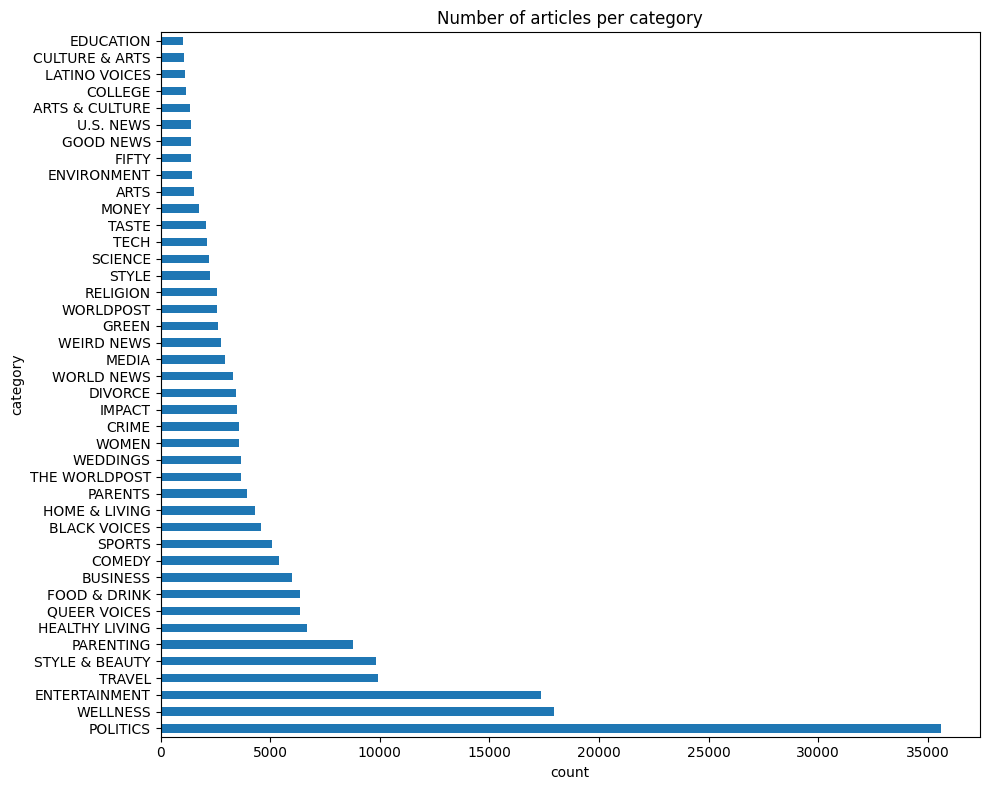

In [175]:
category_counts = df["category"].value_counts()

plt.figure(figsize=(10,8))
category_counts.plot(kind="barh")

plt.title("Number of articles per category")
plt.xlabel("count")
plt.ylabel("category")

plt.tight_layout()
plt.show()

Combine headline and short description to give the model more information to learn from. So the new column headline_description will be the input

In [176]:
df["headline_description"] = (df["headline"] + " " + df["short_description"]).str.strip() #str.strip() to remove leading and trailing space

pd.set_option('display.max_colwidth', None) #show full width of columns to have a clear read on headline_description

df.sample(5)

,link,headline,category,short_description,authors,date,headline_description
31620,https://www.huffingtonpost.com/entry/bill-clinton-zings-trump-administration-at-alec-baldwin-roast_us_5950d1dce4b0da2c731c9ca7,Bill Clinton Zings Trump Administration At Alec Baldwin Roast,POLITICS,"""I wouldn't know an alternative fact if it hit me in the face.""",Ron Dicker,2017-06-26,"Bill Clinton Zings Trump Administration At Alec Baldwin Roast ""I wouldn't know an alternative fact if it hit me in the face."""
184181,https://www.huffingtonpost.com/entry/new-parents_us_5b9c5ab0e4b03a1dcc7e0044,"Moms Are Bungling, Too",PARENTING,"Every time the ""clueless new dad"" archetype appears on TV, the argument among dad bloggers invariably states that dads are as capable as their female counterparts. I'd like to suggest a bold new argument: Yes, dads are clueless when it comes to parenting, but so are moms.","David Vienna, Contributor\nScreenwriter, playwright and author of TheDaddyComplex.com and...",2012-10-26,"Moms Are Bungling, Too Every time the ""clueless new dad"" archetype appears on TV, the argument among dad bloggers invariably states that dads are as capable as their female counterparts. I'd like to suggest a bold new argument: Yes, dads are clueless when it comes to parenting, but so are moms."
5632,https://www.huffpost.com/entry/neil-patrick-harris-david-burtka-nyc-christmas-decorations_n_5df27758e4b024ea5ac6f4d6,Here's How Neil Patrick Harris And David Burtka Plan To Celebrate Christmas In Style,ENTERTAINMENT,The couple took Architectural Digest on a tour of their NYC home decked out in holiday splendor.,Curtis M. Wong,2019-12-12,Here's How Neil Patrick Harris And David Burtka Plan To Celebrate Christmas In Style The couple took Architectural Digest on a tour of their NYC home decked out in holiday splendor.
169167,https://www.huffingtonpost.com/entry/paid-vacation-holidays_us_5b9d0123e4b03a1dcc83b34e,Paid Vacation Mandated Almost Everywhere But U.S. (INFOGRAPHIC),WELLNESS,"As the U.S. Department of Labor states, ""The Fair Labor Standards Act (FLSA) does not require payment for time not worked",Katy Hall and Chris Spurlock,2013-04-05,"Paid Vacation Mandated Almost Everywhere But U.S. (INFOGRAPHIC) As the U.S. Department of Labor states, ""The Fair Labor Standards Act (FLSA) does not require payment for time not worked"
88085,https://www.huffingtonpost.com/entry/pope-francis-is-saying-what-the-world-needs-to-hear_us_5600a99ae4b00310edf8548f,Pope Francis Is Saying What The World Needs To Hear,RELIGION,"On poverty, peace and the planet.",Antonia Blumberg,2015-09-23,"Pope Francis Is Saying What The World Needs To Hear On poverty, peace and the planet."


#check null entries on headline_description

In [177]:
df["headline_description"].isna().sum()

np.int64(0)

Select specific cataegories for classififcation but also reduce the number of samples. Reasons: 
- Reduce classes for a better interpretation of the model 
- class imbalance

In [178]:
selected_categories = ["POLITICS", "BUSINESS", "SPORTS", "TECH", "SCIENCE", "ENTERTAINMENT"]

# new dataframe with the selected categories
selected_df = df[df["category"].isin(selected_categories)]
selected_df.sample(5)

,link,headline,category,short_description,authors,date,headline_description
31350,https://www.huffingtonpost.com/entry/mike-noel-utah-wildfire_us_5954a8ebe4b05c37bb7bf1ee,Utah Lawmaker Blames 'Treehuggers' And 'Rock-Lickers' For Wildfires,POLITICS,"Environmentalists say he's exploiting the blaze to ""mislead the public.”",Nick Visser,2017-06-29,"Utah Lawmaker Blames 'Treehuggers' And 'Rock-Lickers' For Wildfires Environmentalists say he's exploiting the blaze to ""mislead the public.”"
121684,https://www.huffingtonpost.com/entry/dyett-chicago-high-school-students_n_5760674.html,Why This Chicago High School Has Only 12 Students Left,POLITICS,,Joseph Erbentraut,2014-09-03,Why This Chicago High School Has Only 12 Students Left
54958,https://www.huffingtonpost.com/entry/2016-nobel-prize-physics_us_57f37862e4b01b16aafec83d,"2016 Nobel Prize In Physics Awarded To David Thouless, Duncan Haldane And Michael Kosterlitz",SCIENCE,They were honored for their work in revealing the secrets of exotic matter.,,2016-10-04,"2016 Nobel Prize In Physics Awarded To David Thouless, Duncan Haldane And Michael Kosterlitz They were honored for their work in revealing the secrets of exotic matter."
2313,https://www.huffpost.com/entry/scabby-rat-union-protest-icon-survives-legal-challenge-trump-appointee_n_60f8baf5e4b0e92dfebf7a6b,"Scabby The Rat, Union Protest Icon, Survives Legal Challenge From Trump Appointee",POLITICS,"You come at Scabby, you best not miss.",Dave Jamieson,2021-07-22,"Scabby The Rat, Union Protest Icon, Survives Legal Challenge From Trump Appointee You come at Scabby, you best not miss."
3690,https://www.huffpost.com/entry/trump-campaign-sidelines-sidney-powell-legal-team_n_5fbb1497c5b61d04bfa2088f,Trump Campaign Sidelines Sidney Powell From Legal Team,POLITICS,The unexpected pivot comes as the attorney continues to make increasingly outrageous and baseless claims of voter fraud in the 2020 election.,Sanjana Karanth,2020-11-23,Trump Campaign Sidelines Sidney Powell From Legal Team The unexpected pivot comes as the attorney continues to make increasingly outrageous and baseless claims of voter fraud in the 2020 election.


In [179]:
selected_df["category"].value_counts()

category
POLITICS         35601
ENTERTAINMENT    17362
BUSINESS          5992
SPORTS            5077
SCIENCE           2206
TECH              2100
Name: count, dtype: int64

Now we reduce the number of sample to 2100 for each category to avoid class imbalance

In [180]:
balanced_df = selected_df.groupby(["category"], group_keys=False).apply(lambda x: x.sample(n=2100)) #group_keys=False to avoid creation of an additional index + #link:https://stackoverflow.com/questions/36390406/sample-each-group-after-pandas-groupby
balanced_df["category"].value_counts()

/tmp/ipykernel_79518/2687431943.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = selected_df.groupby(["category"], group_keys=False).apply(lambda x: x.sample(n=2100)) #group_keys=False to avoid creation of an additional index + #link:https://stackoverflow.com/questions/36390406/sample-each-group-after-pandas-groupby


category
BUSINESS         2100
ENTERTAINMENT    2100
POLITICS         2100
SCIENCE          2100
SPORTS           2100
TECH             2100
Name: count, dtype: int64

In [181]:
#inputs and labels
X = balanced_df["headline_description"]
y = balanced_df["category"]

##### Train/Test split

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [183]:
class NewsClassifier:
  def __init__(self, vectorizer, model):
    self.vectorizer = vectorizer
    self.model = model
    
  def train(self, X_train, y_train):
    X_train = self.vectorizer.fit_transform(X_train)
    self.model.fit(X_train, y_train)
    
  def predict(self, X_test):
    X_test = self.vectorizer.transform(X_test)
    predictions = self.model.predict(X_test)
    return predictions
  
  def evaluate(self, y_pred, y_test):
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("Macro-F1:", f1_score(y_test, y_pred, average="macro"))
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:\n")
    print(confusion_matrix(y_test, y_pred))
    
  def extract_keywords(self, text, top_n=5):
    X = self.vectorizer.transform(text)
    scores = dict(zip(self.vectorizer.get_feature_names_out(), X.toarray()[0])) #map features names(or keywords) to score + link:https://stackoverflow.com/questions/53294482/how-to-get-tf-idf-scores-for-the-words
    scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))
    top_keywords = dict(list(scores.items())[:top_n]) #convert to list, slice then convert back to dict
    return [word for word in top_keywords] #python iterates over the keys to output the top_n keywords

### Models: Logistic Regression vs Multinomial Naive Bayes

In [184]:
#vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2))

#### Logistic Regression

In [185]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
clf_1 = NewsClassifier(vectorizer=vectorizer, model=lr)
clf_1.train(X_train=X_train, y_train=y_train)
y_pred = clf_1.predict(X_test=X_test)
clf_1.evaluate(y_pred=y_pred, y_test=y_test)


Accuracy: 0.7821428571428571
Macro-F1: 0.7831957975835225

Classification report:

               precision    recall  f1-score   support

     BUSINESS       0.63      0.76      0.69       403
ENTERTAINMENT       0.79      0.76      0.77       428
     POLITICS       0.80      0.82      0.81       414
      SCIENCE       0.83      0.82      0.82       414
       SPORTS       0.89      0.82      0.85       434
         TECH       0.80      0.72      0.76       427

     accuracy                           0.78      2520
    macro avg       0.79      0.78      0.78      2520
 weighted avg       0.79      0.78      0.78      2520

Confusion matrix:

[[307  13  21  14   8  40]
 [ 19 325  36  19  14  15]
 [ 35  16 339  10   7   7]
 [ 36  13   5 339   7  14]
 [ 27  29  14   7 354   3]
 [ 64  18  10  19   9 307]]


#### Multinomial Naive Bayes

In [186]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
clf_2 = NewsClassifier(vectorizer=vectorizer, model=mnb)
clf_2.train(X_train=X_train, y_train=y_train)
y_pred_2 = clf_2.predict(X_test=X_test)
clf_2.evaluate(y_pred=y_pred_2, y_test=y_test)


Accuracy: 0.7928571428571428
Macro-F1: 0.7950586033034277

Classification report:

               precision    recall  f1-score   support

     BUSINESS       0.62      0.81      0.70       403
ENTERTAINMENT       0.87      0.74      0.80       428
     POLITICS       0.77      0.85      0.81       414
      SCIENCE       0.87      0.81      0.84       414
       SPORTS       0.94      0.83      0.88       434
         TECH       0.77      0.73      0.75       427

     accuracy                           0.79      2520
    macro avg       0.81      0.79      0.80      2520
 weighted avg       0.81      0.79      0.80      2520

Confusion matrix:

[[326   7  26   9   1  34]
 [ 28 316  36  13  11  24]
 [ 34   9 352   6   6   7]
 [ 43   5   9 334   3  20]
 [ 25  16  20   7 360   6]
 [ 70  12  17  14   4 310]]


Check the prediction of a sample and extract keywords 

In [187]:
sample_text = X_test.iloc[0]
sample_text = [sample_text] #Why ? -> ValueError so fix was https://stackoverflow.com/questions/49806790/iterable-over-raw-text-documents-expected-string-object-received
true_label = y_test.iloc[0]

#Logistic Regression
print(f"Sample text: {sample_text}")
print(f"True Label: {true_label}")
print()
prediction = clf_1.predict(sample_text)
keywords = clf_1.extract_keywords(sample_text)
print(f"predicted label: {prediction}")
print(f"Keywords: {keywords}")

Sample text: ["Poll Finds Near-Universal Support For Gun Background Checks It's the most support the Quinnipiac University Poll has ever measured."]
True Label: POLITICS

predicted label: ['POLITICS']
Keywords: ['poll', 'support', 'background checks', 'gun background', 'for gun']


In [188]:
#Multinomial Naive Bayes
prediction = clf_2.predict(sample_text)
keywords = clf_2.extract_keywords(sample_text)
print(f"predicted label: {prediction}")
print(f"Keywords: {keywords}")

predicted label: ['POLITICS']
Keywords: ['poll', 'support', 'background checks', 'gun background', 'for gun']
